In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier
)
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [2]:
DATA_DIR = Path("../data/processed")
SUBMISSION_DIR = Path("../submission")

train_features = pd.read_csv(
    DATA_DIR / "train_features.csv"
)

test_features = pd.read_csv(
    DATA_DIR / "test_features.csv"
)

# Convert dates
train_features["signal_sanasi"] = pd.to_datetime(
    train_features["signal_sanasi"]
)

test_features["signal_sanasi"] = pd.to_datetime(
    test_features["signal_sanasi"]
)

print("Train features:", train_features.shape)
print("Test features:", test_features.shape)
print("Columns:", train_features.columns.tolist())

Train features: (14000, 25)
Test features: (6000, 24)
Columns: ['signal_id', 'transaction_count', 'miqdor_mean', 'miqdor_median', 'miqdor_std', 'miqdor_min', 'miqdor_max', 'chiqim_count', 'kirim_count', 'kirim_ratio', 'bank_otkazmasi_count', 'karta_count', 'naqd_count', 'xalqaro_count', 'tx_1d', 'tx_3d', 'tx_7d', 'tx_30d', 'miqdor_q10', 'miqdor_q25', 'miqdor_q75', 'miqdor_q90', 'miqdor_iqr', 'signal_sanasi', 'eskalatsiya']


In [3]:
feature_cols = [
    "transaction_count",
    "miqdor_mean",
    "miqdor_median",
    "miqdor_std",
    "miqdor_min",
    "miqdor_max",
    "chiqim_count",
    "kirim_count",
    "kirim_ratio",
    "bank_otkazmasi_count",
    "karta_count",
    "naqd_count",
    "xalqaro_count",
    "tx_1d",
    "tx_3d",
    "tx_7d",
    "tx_30d",
    "miqdor_q10",
    "miqdor_q25",
    "miqdor_q75",
    "miqdor_q90",
    "miqdor_iqr"
]

X = train_features[feature_cols]
y = train_features["eskalatsiya"]
X_test = test_features[feature_cols]

print("X:", X.shape)
print("y:", y.shape)
print("X_test:", X_test.shape)

X: (14000, 22)
y: (14000,)
X_test: (6000, 22)


## 1. Baseline Model

Logistic Regression is used as a simple baseline.

The purpose is not to obtain the best score, but to establish a reference point for more complex models.

In [4]:
split_date = train_features["signal_sanasi"].quantile(0.8)

train_mask = train_features["signal_sanasi"] < split_date
val_mask = train_features["signal_sanasi"] >= split_date

X_train = train_features.loc[train_mask, feature_cols]
y_train = train_features.loc[train_mask, "eskalatsiya"]

X_val = train_features.loc[val_mask, feature_cols]
y_val = train_features.loc[val_mask, "eskalatsiya"]

print("Split date:", split_date)
print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Split date: 2026-06-06 00:00:00
Train: (11183, 22)
Validation: (2817, 22)


In [5]:
baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict_proba(X_val)[:, 1]

baseline_auc = roc_auc_score(
    y_val,
    baseline_pred
)

print(f"Logistic Regression ROC-AUC: {baseline_auc:.4f}")

Logistic Regression ROC-AUC: 0.5791


/Users/mmm/Developer/hackatohn/Fintech-AI-WUIT_hackathon/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 2. Model Comparison

Several classical ML models are evaluated using the same time-based validation split.

In [6]:
models = {
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=15,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=5,
        learning_rate=0.03,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False
    )
}

In [7]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    pred = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, pred)

    results.append({
        "model": name,
        "roc_auc": auc
    })

results_df = pd.DataFrame(results)

results_df

,model,roc_auc
0,HistGradientBoosting,0.616052
1,Random Forest,0.601082
2,XGBoost,0.601172
3,CatBoost,0.603526


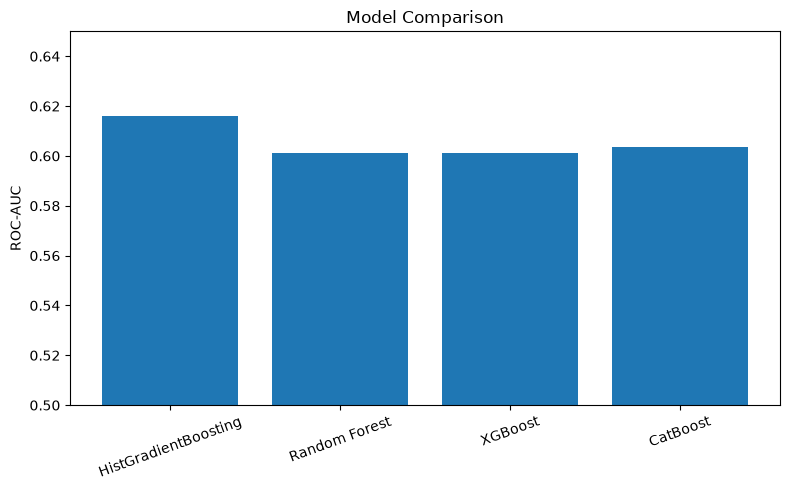

In [8]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["model"],
    results_df["roc_auc"]
)

plt.ylabel("ROC-AUC")
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.ylim(0.5, 0.65)

plt.tight_layout()
plt.show()

## 3. HistGradientBoosting Tuning

HistGradientBoosting showed the strongest performance among the tested models.

Several configurations were tested by changing:
- learning rate
- number of iterations
- number of leaf nodes

In [9]:
hgb_configs = {
    "HGB v1": {
        "max_iter": 300,
        "learning_rate": 0.05,
        "max_leaf_nodes": 15
    },

    "HGB v2": {
        "max_iter": 500,
        "learning_rate": 0.05,
        "max_leaf_nodes": 31,
        "l2_regularization": 1.0
    },

    "HGB v3": {
        "max_iter": 300,
        "learning_rate": 0.03,
        "max_leaf_nodes": 15
    }
}

In [10]:
hgb_results = []

for name, params in hgb_configs.items():

    model = HistGradientBoostingClassifier(
        **params,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, pred)

    hgb_results.append({
        "model": name,
        "roc_auc": auc
    })

hgb_results_df = pd.DataFrame(hgb_results)

hgb_results_df

,model,roc_auc
0,HGB v1,0.616052
1,HGB v2,0.608047
2,HGB v3,0.621216


In [11]:
best_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.03,
    max_leaf_nodes=15,
    random_state=42
)

best_model.fit(X_train, y_train)

val_pred = best_model.predict_proba(X_val)[:, 1]

val_auc = roc_auc_score(
    y_val,
    val_pred
)

print(f"Validation ROC-AUC: {val_auc:.4f}")

Validation ROC-AUC: 0.6212


## 4. Feature Importance

Permutation importance is used to estimate how much each feature contributes to validation performance.

A feature is considered important if shuffling it noticeably decreases ROC-AUC.

In [12]:
importance = permutation_importance(
    best_model,
    X_val,
    y_val,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importance.importances_mean
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df

,feature,importance
4,miqdor_min,0.067955
5,miqdor_max,0.015782
6,chiqim_count,0.015084
8,kirim_ratio,0.004775
11,naqd_count,0.003745
9,bank_otkazmasi_count,0.003552
3,miqdor_std,0.003001
18,miqdor_q25,0.002978
10,karta_count,0.002471
16,tx_30d,0.001828


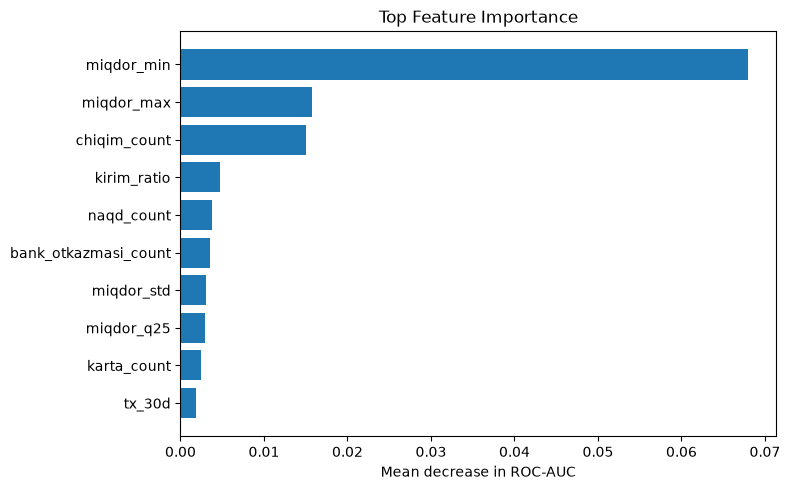

In [13]:
top_n = 10

plot_df = importance_df.head(top_n).sort_values(
    "importance"
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_df["feature"],
    plot_df["importance"]
)

plt.xlabel("Mean decrease in ROC-AUC")
plt.title("Top Feature Importance")

plt.tight_layout()
plt.show()

## 5. Temporal Stability

Because the task is time-dependent, model performance is evaluated on several future time periods.

This helps determine whether the model behaves consistently over time.

In [14]:
data = train_features.sort_values(
    "signal_sanasi"
).reset_index(drop=True)

splits = [
    ("2026-03-30", "2026-05-31", "2026-03 → 2026-05"),
    ("2026-06-01", "2026-08-31", "2026-06 → 2026-08"),
    ("2026-09-01", "2026-12-31", "2026-09 → 2026-12")
]

temporal_results = []

for val_start, val_end, period in splits:

    train_mask = data["signal_sanasi"] < val_start

    val_mask = (
        (data["signal_sanasi"] >= val_start) &
        (data["signal_sanasi"] <= val_end)
    )

    X_train_time = data.loc[
        train_mask,
        feature_cols
    ]

    y_train_time = data.loc[
        train_mask,
        "eskalatsiya"
    ]

    X_val_time = data.loc[
        val_mask,
        feature_cols
    ]

    y_val_time = data.loc[
        val_mask,
        "eskalatsiya"
    ]

    model = HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.03,
        max_leaf_nodes=15,
        random_state=42
    )

    model.fit(
        X_train_time,
        y_train_time
    )

    pred = model.predict_proba(
        X_val_time
    )[:, 1]

    auc = roc_auc_score(
        y_val_time,
        pred
    )

    temporal_results.append({
        "period": period,
        "roc_auc": auc
    })

temporal_results_df = pd.DataFrame(
    temporal_results
)

temporal_results_df

,period,roc_auc
0,2026-03 → 2026-05,0.588279
1,2026-06 → 2026-08,0.592624
2,2026-09 → 2026-12,0.634032


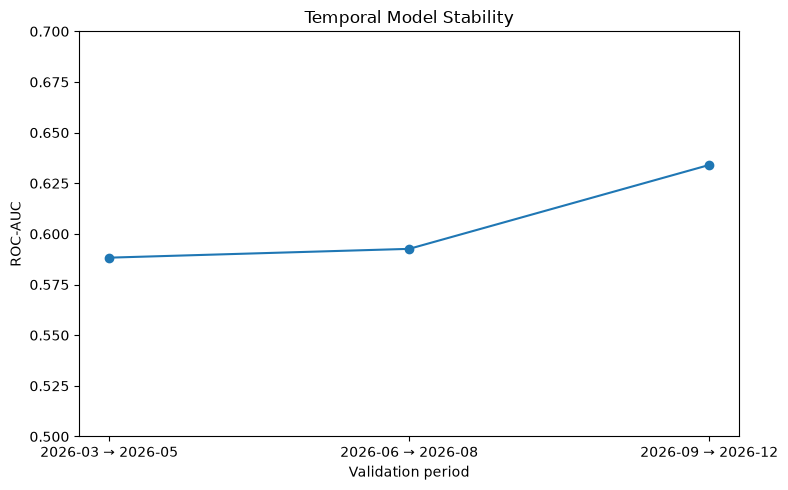

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    temporal_results_df["period"],
    temporal_results_df["roc_auc"],
    marker="o"
)

plt.ylabel("ROC-AUC")
plt.xlabel("Validation period")
plt.title("Temporal Model Stability")

plt.ylim(0.5, 0.7)

plt.tight_layout()
plt.show()

## 6. Final Model

The selected HistGradientBoosting configuration is trained on the complete training dataset before generating predictions for the test set.

In [16]:
final_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.03,
    max_leaf_nodes=15,
    random_state=42
)

final_model.fit(
    X,
    y
)

test_pred = final_model.predict_proba(
    X_test
)[:, 1]

print("Predictions:", len(test_pred))
print("Min:", test_pred.min())
print("Max:", test_pred.max())
print("Mean:", test_pred.mean())

Predictions: 6000
Min: 0.10717992681759916
Max: 0.3100032978188698
Mean: 0.17180254153899485


In [17]:
submission = pd.DataFrame({
    "signal_id": test_features["signal_id"],
    "ehtimollik": test_pred
})

SUBMISSION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

submission.to_csv(
    SUBMISSION_DIR / "submission.csv",
    index=False
)

submission.head()

,signal_id,ehtimollik
0,SG_000001,0.147323
1,SG_000007,0.208634
2,SG_000009,0.133614
3,SG_000010,0.131931
4,SG_000011,0.112976


## 7. Submission Validation

The submission must contain exactly one prediction for every test signal.

In [18]:
print("Submission shape:", submission.shape)
print("Expected rows:", len(test_features))

print(
    "Unique IDs:",
    submission["signal_id"].nunique()
)

print(
    "Missing IDs:",
    submission["signal_id"].isna().sum()
)

print(
    "Missing predictions:",
    submission["ehtimollik"].isna().sum()
)

print(
    "Predictions < 0:",
    (submission["ehtimollik"] < 0).sum()
)

print(
    "Predictions > 1:",
    (submission["ehtimollik"] > 1).sum()
)

print(
    "Unknown IDs:",
    (~submission["signal_id"].isin(
        test_features["signal_id"]
    )).sum()
)

print(
    "Missing test IDs:",
    (~test_features["signal_id"].isin(
        submission["signal_id"]
    )).sum()
)

Submission shape: (6000, 2)
Expected rows: 6000
Unique IDs: 6000
Missing IDs: 0
Missing predictions: 0
Predictions < 0: 0
Predictions > 1: 0
Unknown IDs: 0
Missing test IDs: 0


In [19]:
assert len(submission) == len(test_features)
assert submission["signal_id"].nunique() == len(test_features)
assert submission["ehtimollik"].isna().sum() == 0
assert (submission["ehtimollik"] >= 0).all()
assert (submission["ehtimollik"] <= 1).all()

assert submission["signal_id"].isin(
    test_features["signal_id"]
).all()

assert test_features["signal_id"].isin(
    submission["signal_id"]
).all()

print("All submission checks passed.")

All submission checks passed.
